In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix
from src.solvers import AugmentedHybridSDPSolver
from src.plants import AugmentedHybridPlant
from src.controllers import (
    build_approach,
    AugmentedFCLockedControl,
    AugmentedPolicyControl,
    AugmentedValueControl,
)

In [4]:
env = EnvConfig()
config = SimConfig(dP=100, N_Pd=7)

fleet_data = load_and_cache_entire_fleet(env)
exclude_days = [1,2,3] 
benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)


⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 100 kW
 -> Grid Dimensions    : N_d=7, N_n=17, N_soc=37, N_fc=33, N_bat=21
 -> Augmented Space |S|: 145,299 states
 -> Action Space |A|   : 357 actions
 -> Est. Big-O Comput. : O(15,866,650,800) operations
 -> Est. RAM Footprint : ~834.18 MB

Loading fleet data from binary cache: c:\Users\ext-adam\Desktop\INTERNSHIP\Mariner\opt_power\data\cache\fleet_data_cache.npz
 -> Cache instantly loaded in 0.108 seconds.


In [5]:
augmented_approaches = {
    "MacroFCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "FCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroPolicy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Policy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroValue": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Value": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
}

 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 10, 11, 12, 13, 14]...


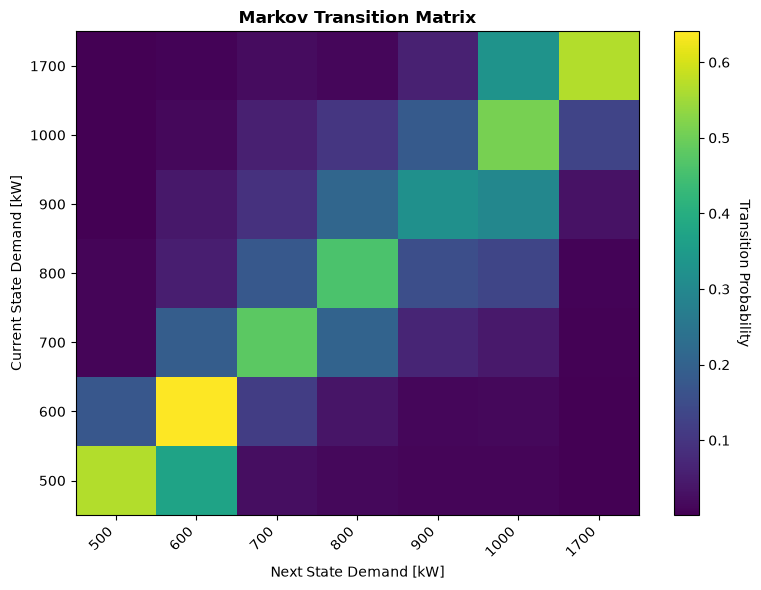

In [6]:
train_days = [4, 5, 6, 7, 8, 10, 11, 12, 13, 14]
test_day = 9
approaches = augmented_approaches

mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)

--- APPROACH A: HAND-PICKED EVALUATION ---
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
| Strategy      | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| MacroFCLocked | 5897.96        | 5643.18            | 147.84             | 33.76            | 62.17              | 24.19                 | -13.18             | 235.14                   | 0.09                    |
| FCLocked      | 6798.98        | 5821.79            | 182.78             | 37.73            | 738.45             | 21.50                 | -3.28              | 235.14                   | 0.49                    |
| MacroPolicy   |

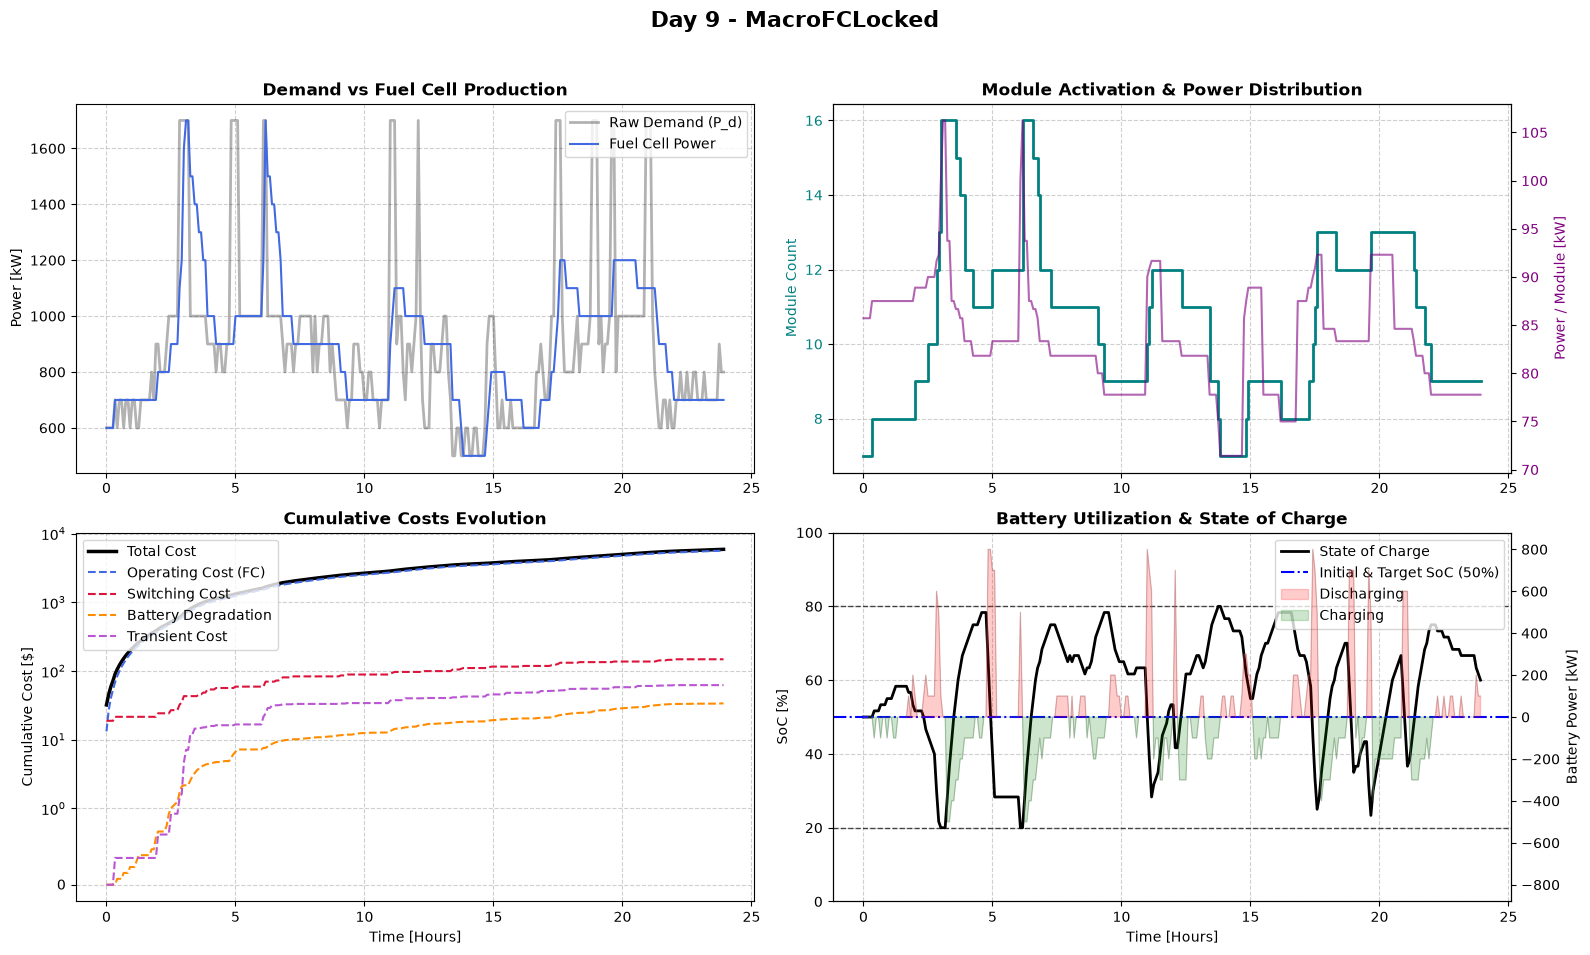

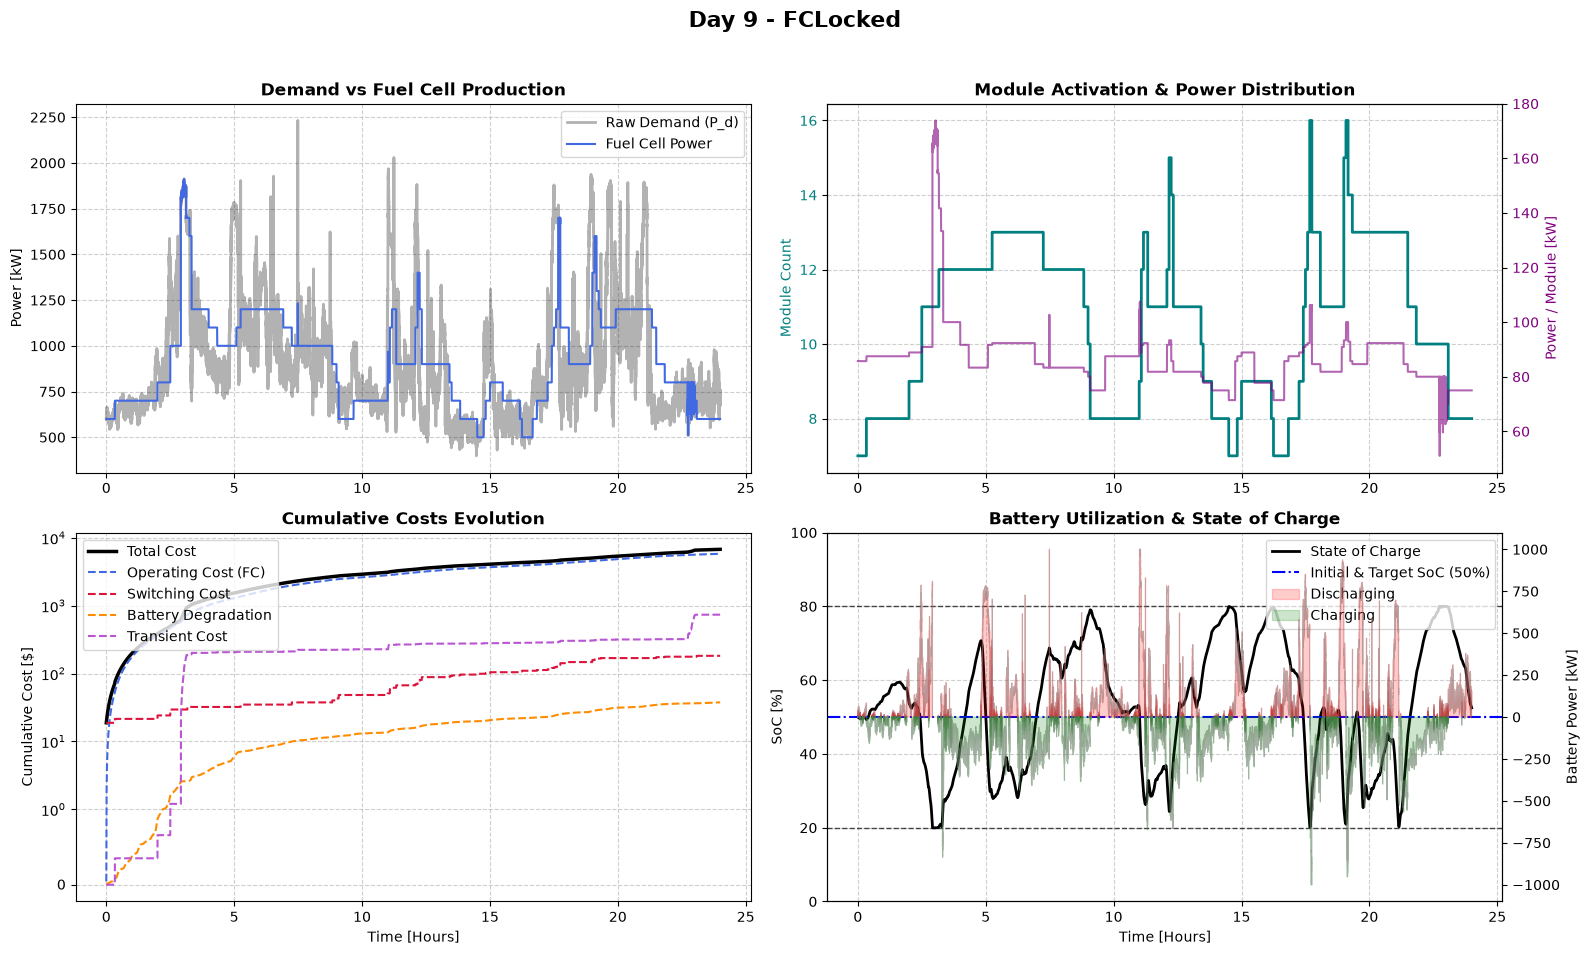

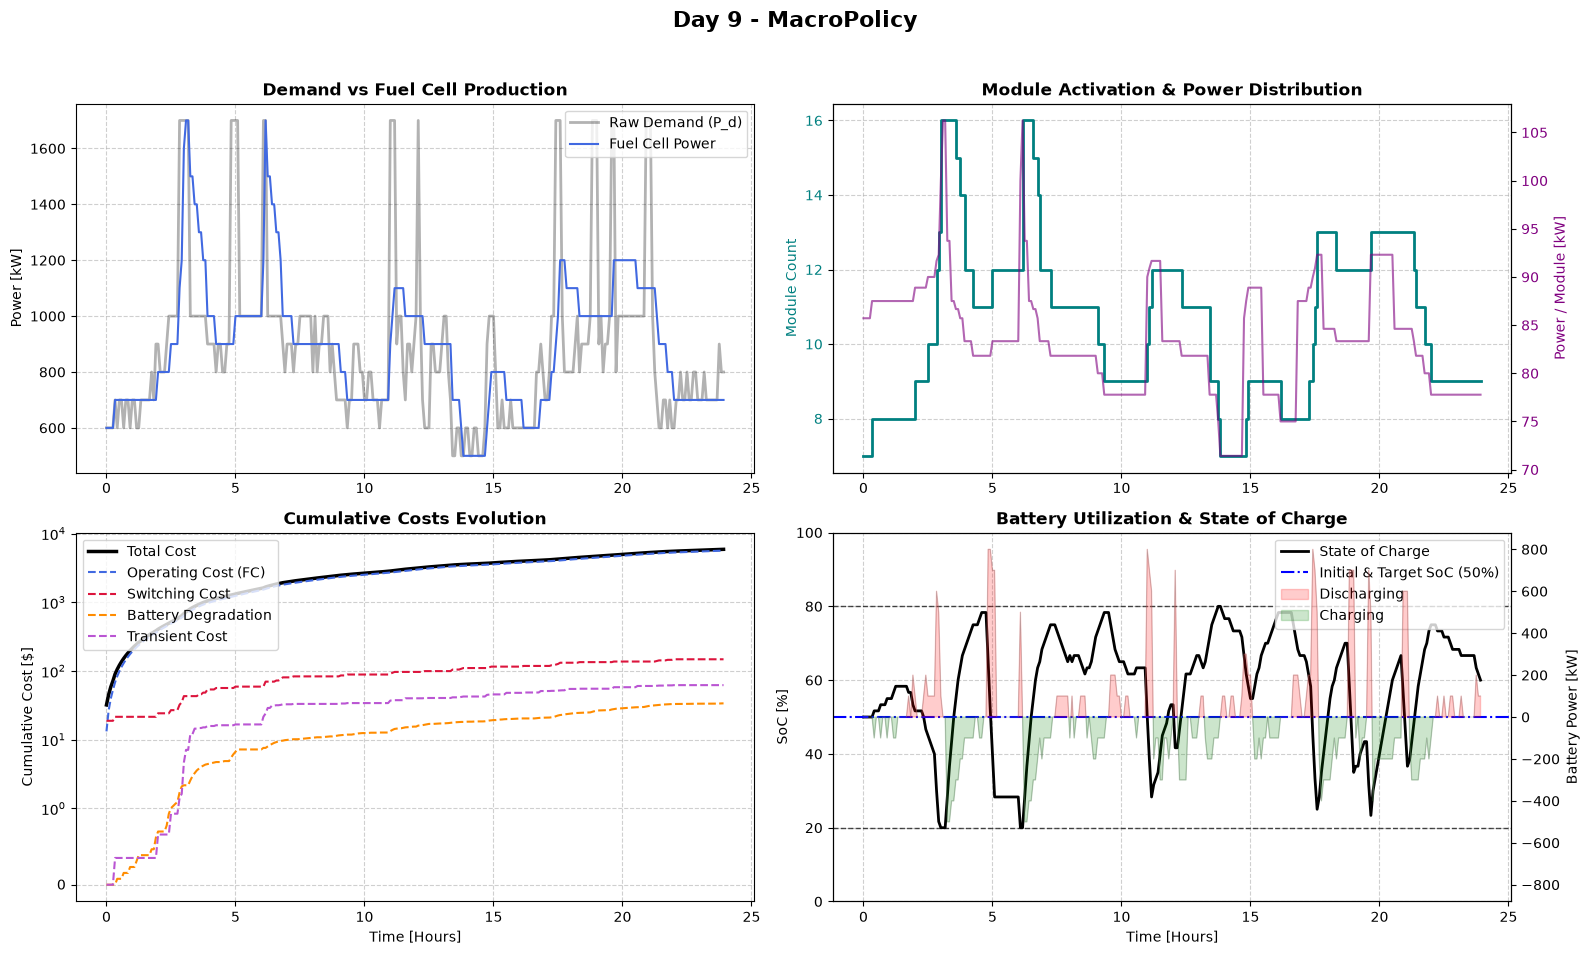

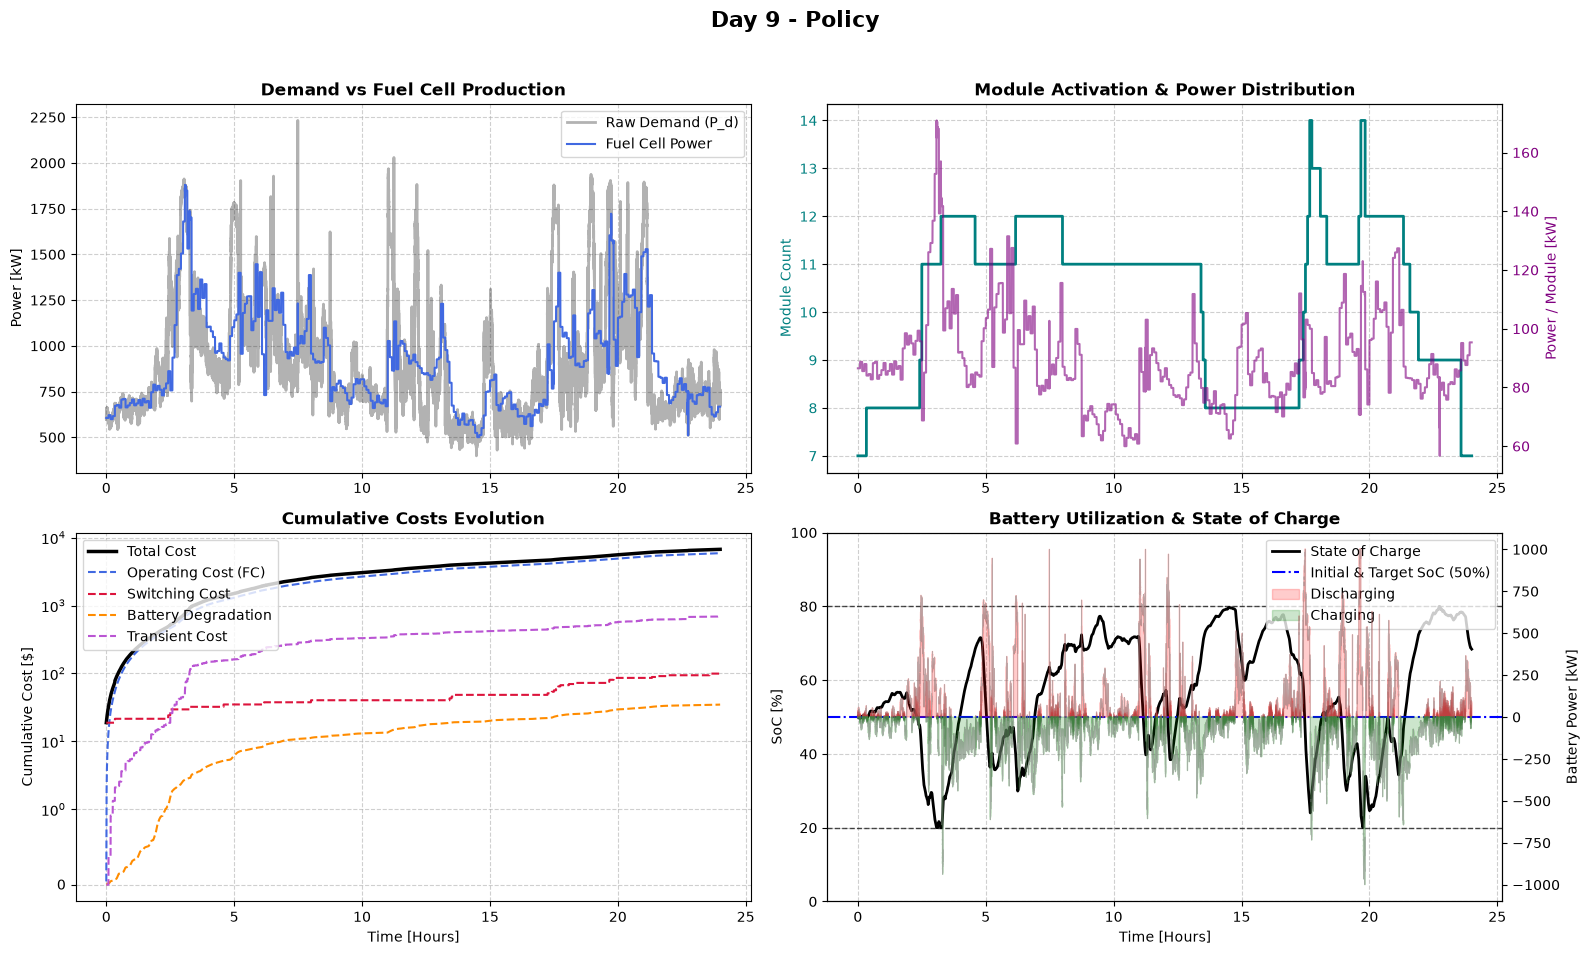

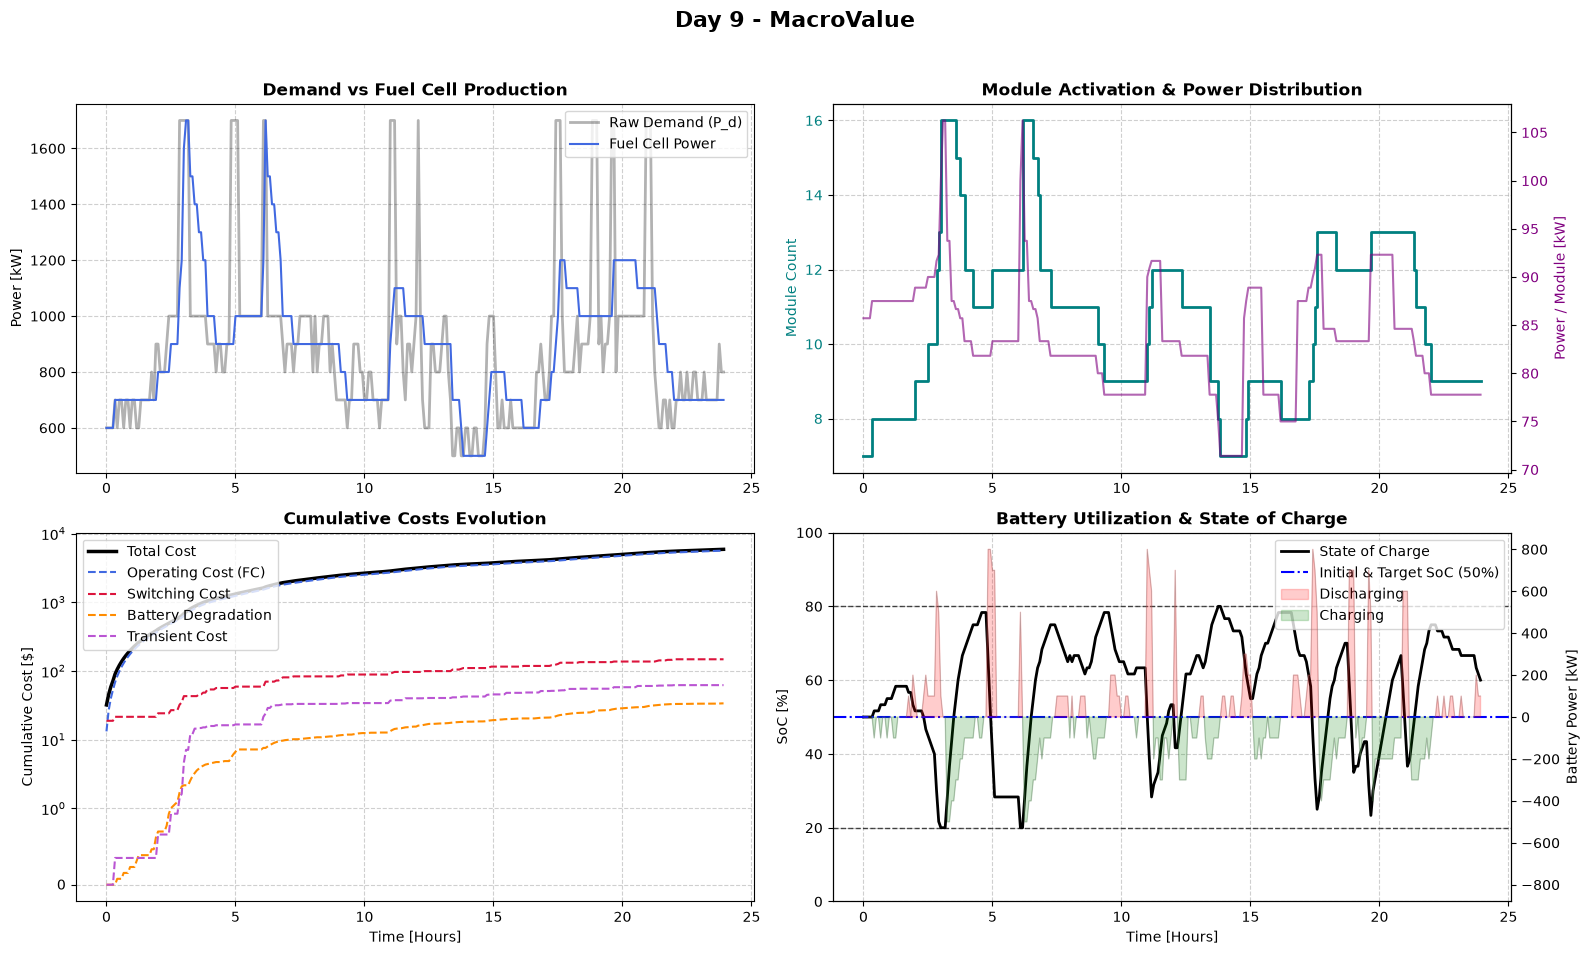

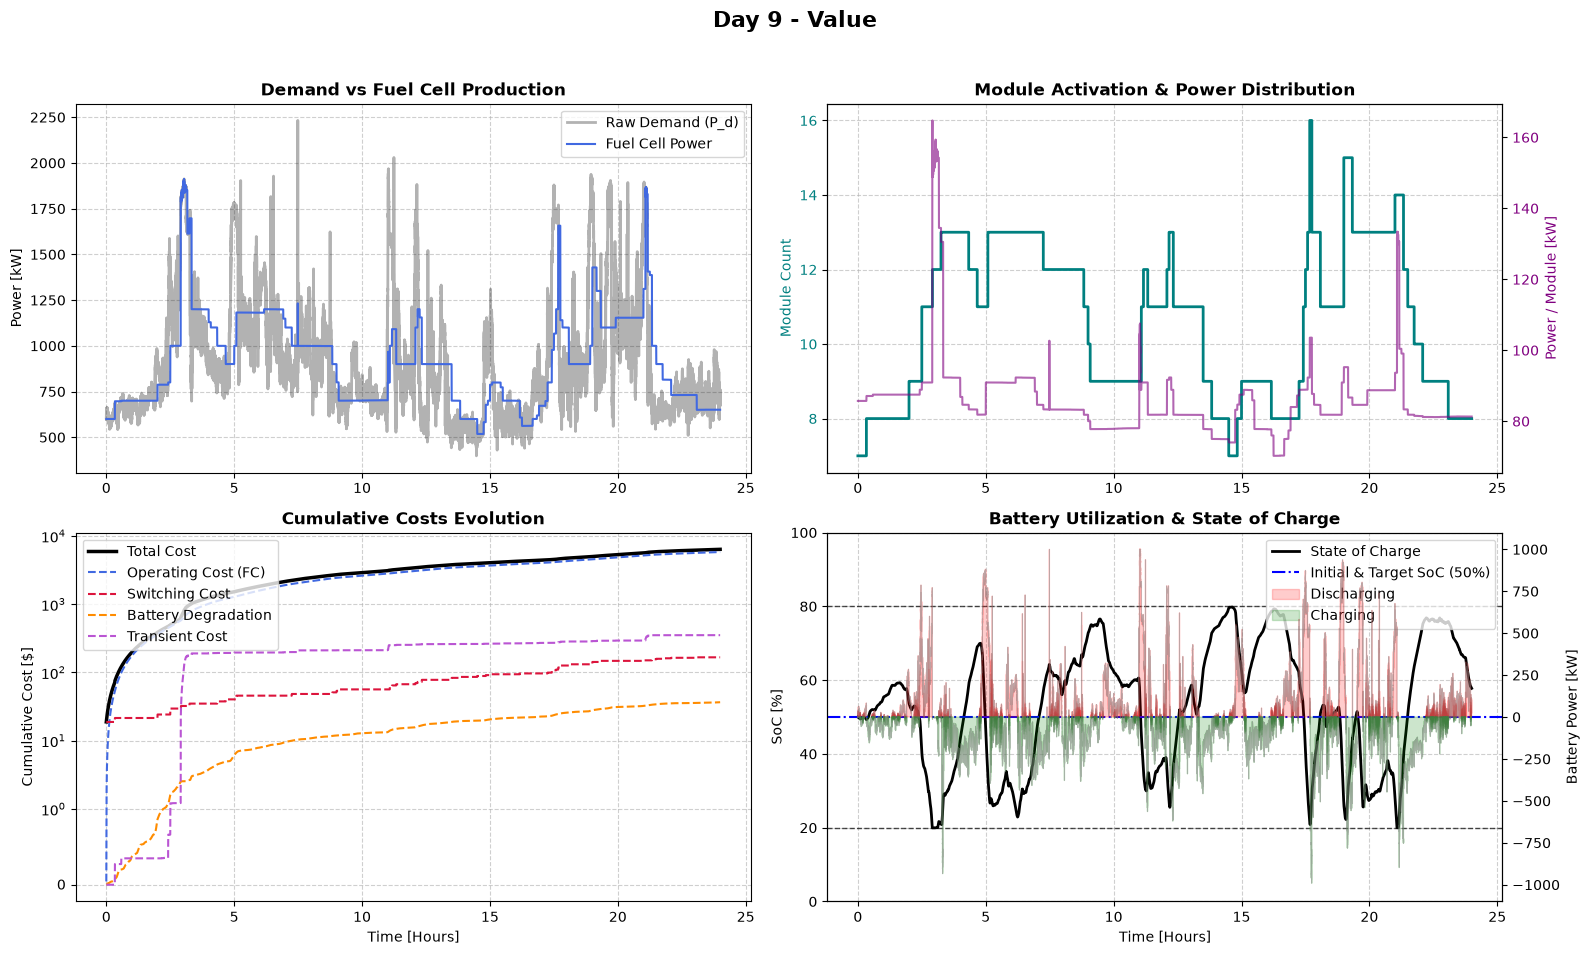

In [7]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)

for app in approaches:
    plot_simulation_dashboard(report.get_telemetry(app), benchmarker.config, title=f"Day {test_day} - {app}", indiv=False)


--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---
 [Vault] Cache MISS: Training Markov Chain for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 11, 12,

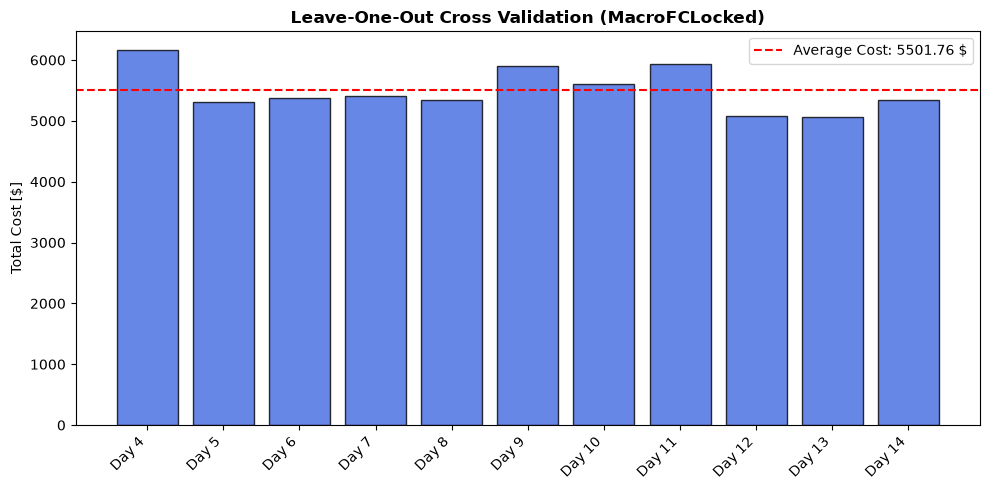

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 4    | 6163.33        | 5896.14            | 123.65             | 37.09            | 55.41              | 26.88                 | 24.17              | 213.09                   | 0.00                    |
| Day 5    | 5310.33        | 5201.06            | 64.51              | 21.99            | 27.63              | 21.50                 | -26.36             | 226.13                   | 0.00                    |
| Day 6    | 5371.90        | 5158.45            | 150.53             | 34.15            | 45.59              | 16.13                 | -32.95             | 231

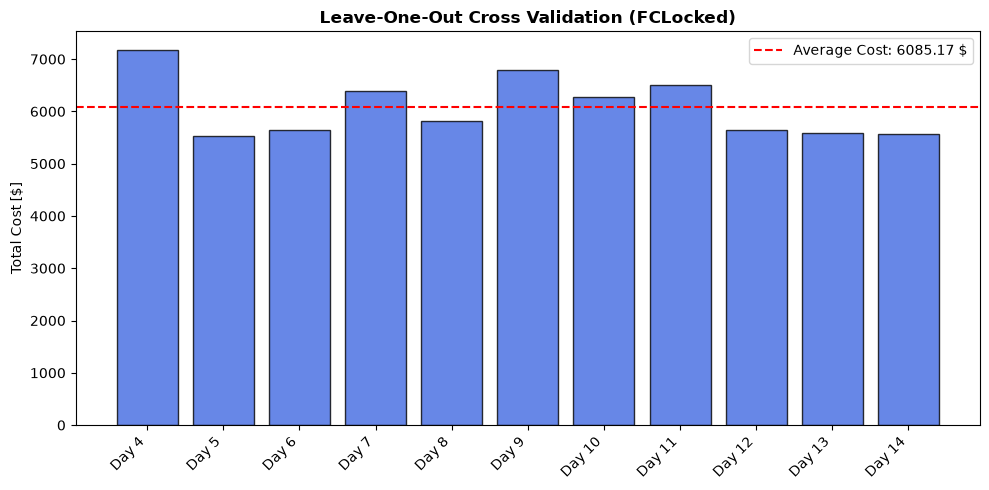

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 4    | 7173.10        | 6134.77            | 155.90             | 41.70            | 793.98             | 26.88                 | 19.87              | 213.09                   | 0.50                    |
| Day 5    | 5531.78        | 5253.42            | 77.95              | 26.01            | 187.96             | 24.19                 | -37.75             | 226.13                   | 0.51                    |
| Day 6    | 5643.75        | 5198.31            | 174.72             | 39.51            | 244.54             | 18.82                 | -32.15             | 231

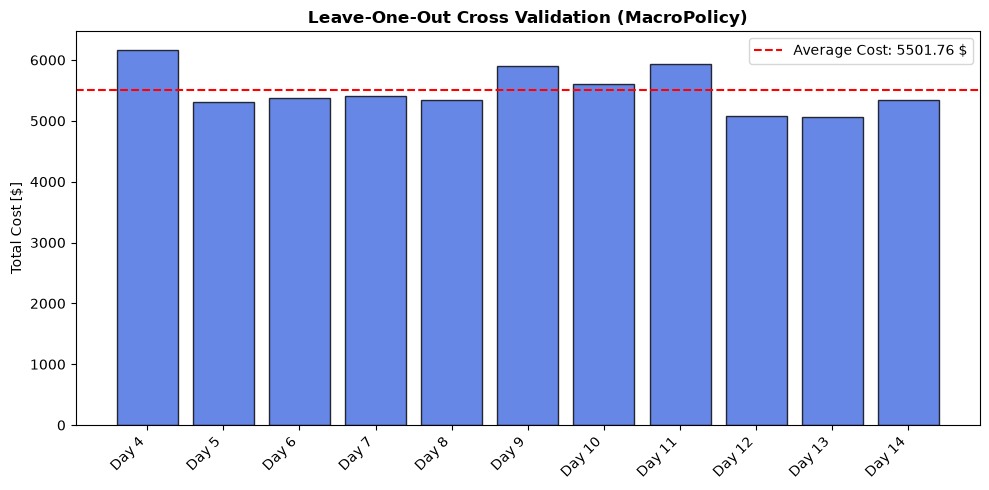

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 4    | 6163.33        | 5896.14            | 123.65             | 37.09            | 55.41              | 26.88                 | 24.17              | 213.09                   | 0.00                    |
| Day 5    | 5310.33        | 5201.06            | 64.51              | 21.99            | 27.63              | 21.50                 | -26.36             | 226.13                   | 0.00                    |
| Day 6    | 5371.90        | 5158.45            | 150.53             | 34.15            | 45.59              | 16.13                 | -32.95             | 231

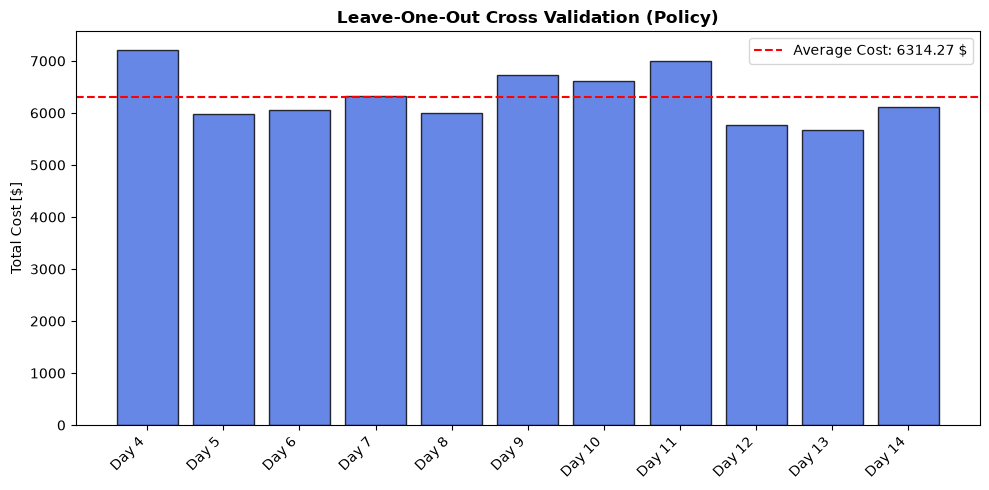

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 4    | 7208.27        | 6119.70            | 142.46             | 42.61            | 847.18             | 29.57                 | 26.75              | 213.09                   | 0.50                    |
| Day 5    | 5983.10        | 5267.69            | 45.70              | 22.67            | 658.76             | 18.82                 | -30.53             | 226.13                   | 0.50                    |
| Day 6    | 6062.99        | 5211.67            | 155.90             | 37.55            | 656.61             | 0.00                  | 1.26               | 231

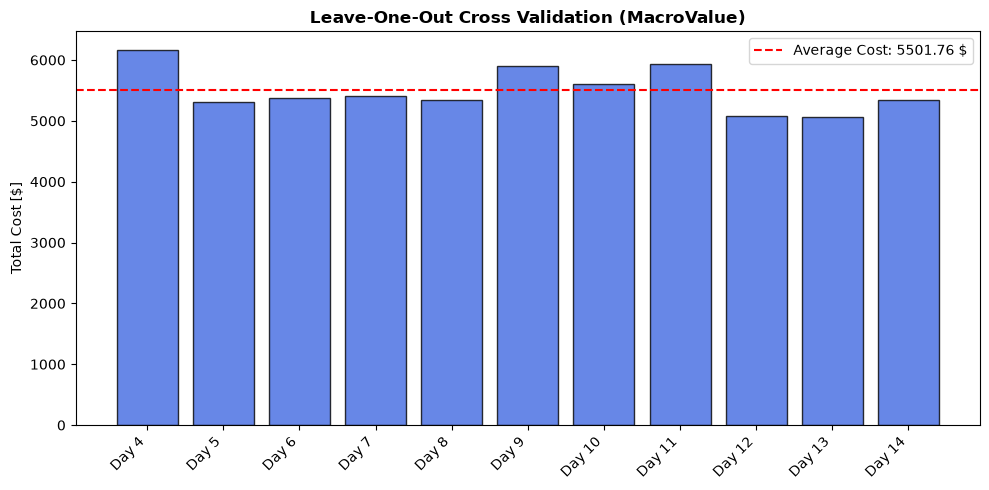

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 4    | 6163.33        | 5896.14            | 123.65             | 37.09            | 55.41              | 26.88                 | 24.17              | 213.09                   | 0.05                    |
| Day 5    | 5310.33        | 5201.06            | 64.51              | 21.99            | 27.63              | 21.50                 | -26.36             | 226.13                   | 0.04                    |
| Day 6    | 5371.90        | 5158.45            | 150.53             | 34.15            | 45.59              | 16.13                 | -32.95             | 231

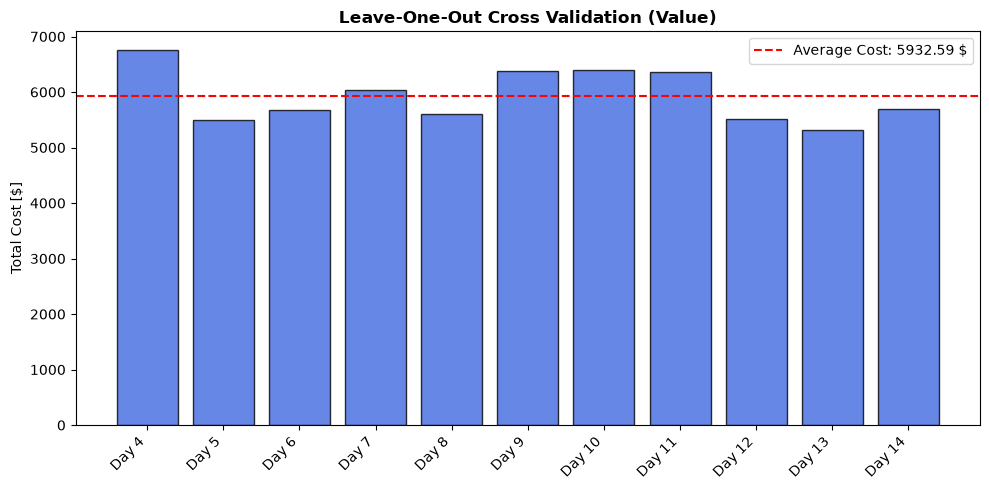

| Strategy | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Transient Cost [$] | Term. Switch Cost [$] | Term. SoC Cost [$] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 4    | 6755.50        | 6052.84            | 161.28             | 42.46            | 447.34             | 26.88                 | 24.71              | 213.09                   | 0.63                    |
| Day 5    | 5491.27        | 5248.66            | 69.89              | 25.21            | 159.13             | 21.50                 | -33.12             | 226.13                   | 0.63                    |
| Day 6    | 5679.72        | 5195.26            | 161.28             | 39.33            | 299.84             | 16.13                 | -32.13             | 231

In [8]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

for app in approaches:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)



In [ ]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p_max = 200 #kW
p_nom = 80 #kW
LHV = 120 #kJ/g
eta_max = 0.6
eta_f = 0.5

alpha = p_max / (p_max - p_nom)**2 * (1/eta_f - 1/eta_max)
beta = 1/eta_max - 2*alpha*p_nom 
gamma = alpha * p_nom ** 2

a, b, c = alpha / LHV, beta / LHV, gamma / LHV

p_vec = np.linspace(0, p_max, 100)
plt.plot(p_vec, a*p_vec**2 + b*p_vec + c)
plt.plot(p_vec, p_vec/(a*p_vec**2 + b*p_vec + c)/LHV)